# 🌙 Low-Light Video Enhancement — Retinexformer

**Mata Kuliah:** Perancangan Citra Digital  
**Metode:** Deep Learning — [Retinexformer (ICCV 2023)](https://arxiv.org/abs/2303.06705)  

> ⚠️ **Notebook ini dirancang untuk dijalankan di Kaggle dengan GPU T4/P100.**  
> Aktifkan GPU di: *Session Options → Accelerator → GPU T4 x2*

---

## Pipeline

```
Frames Input (dari Kaggle Dataset)
    │
    ▼
Retinexformer Inference (batch_infer.py)
    │
    ▼
Enhanced Frames  →  Combine  →  Video Output
                 →  Comparison PNG  →  /kaggle/working/results/
```

### Tentang Retinexformer
Retinexformer menggunakan **Illumination-Guided Transformer** berbasis teori Retinex:
gambar didekomposisi menjadi komponen *illumination* dan *reflectance*, lalu
transformer memperbaiki keduanya secara adaptif.

## ⚙️ Konfigurasi

Sesuaikan path dataset Kaggle dan model yang dipakai.

In [ ]:
# ============================================================
# KONFIGURASI — sesuaikan bagian ini
# ============================================================

INPUT_DIR    = "/kaggle/input/datasets/akmalfayyazi/framess/frames-tanpa-motor/frames"
MODEL_NAME   = "SDSD_outdoor"
MAX_SIDE     = 2560
FPS          = 30

# ============================================================
# Path otomatis (tidak perlu diubah)
# ============================================================

import os

MODEL_CONFIG = f"Options/RetinexFormer_{MODEL_NAME}.yml"
MODEL_WEIGHT = f"pretrained_weights/{MODEL_NAME}.pth"

ENHANCED_DIR = f"/kaggle/working/enhanced_frames_{MODEL_NAME}"
OUTPUT_VIDEO = f"/kaggle/working/output-retinex-{MODEL_NAME}.mp4"
RESULTS_DIR  = "/kaggle/working/results"

for d in [ENHANCED_DIR, RESULTS_DIR, os.path.dirname(OUTPUT_VIDEO)]:
    os.makedirs(d, exist_ok=True)

print("✅ Konfigurasi berhasil dimuat")
print(f"   Input dir    : {INPUT_DIR}")
print(f"   Model        : {MODEL_NAME}")
print(f"   Config       : {MODEL_CONFIG}")
print(f"   Weights      : {MODEL_WEIGHT}")
print(f"   Enhanced dir : {ENHANCED_DIR}")
print(f"   Output video : {OUTPUT_VIDEO}")

✅ Konfigurasi berhasil dimuat
   Input dir    : /kaggle/input/datasets/akmalfayyazi/framess/frames-tanpa-motor/frames
   Model        : SDSD_outdoor
   Config       : Options/RetinexFormer_SDSD_outdoor.yml
   Weights      : pretrained_weights/SDSD_outdoor.pth
   Enhanced dir : /kaggle/working/enhanced_frames_SDSD_outdoor
   Output video : /kaggle/working/output-retinex-SDSD_outdoor.mp4


---
## Step 1 — Install Dependencies & Clone Retinexformer

In [2]:
!git clone https://github.com/caiyuanhao1998/Retinexformer
%cd Retinexformer
!pip install -q matplotlib scikit-learn scikit-image opencv-python yacs joblib natsort \
    h5py tqdm tensorboard einops gdown addict future lmdb numpy pyyaml requests \
    scipy yapf lpips thop timm
!python setup.py develop --no_cuda_ext

Cloning into 'Retinexformer'...
remote: Enumerating objects: 712, done.
remote: Counting objects: 100% (269/269), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 712 (delta 243), reused 188 (delta 188), pack-reused 443 (from 2)
Receiving objects: 100% (712/712), 16.30 MiB | 46.88 MiB/s, done.
Resolving deltas: 100% (383/383), done.
/kaggle/working/Retinexformer
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 58.0 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-

---
## Step 2 — Download Pretrained Weights

In [3]:
!gdown --folder https://drive.google.com/drive/folders/1ynK5hfQachzc8y96ZumhkPPDXzHJwaQV -O pretrained_weights_all
!mkdir -p pretrained_weights
!find pretrained_weights_all -iname "{MODEL_NAME}.pth" -exec cp {{}} pretrained_weights/ \;
!ls pretrained_weights

Retrieving folder contents
Retrieving folder 15bEHNveVvYKGrXmqDpBiaBxXTyxinsl5 MST_Plus_Plus_NTIRE
Processing file 11uTfmk6GCseVAyTFwLzaztmUP4rKrOQC MST_Plus_Plus_4x1800.pth
Processing file 1EUX513nFaoG_LLxkxuDZMl0EWRxW-R3A MST_Plus_Plus_8x1150.pth
Processing file 1oxvPPfhbOwZURTFenWnFp3H3Lakkqw3t FiveK.pth
Processing file 1xDwQtTCj3tlAVCTJgYrzonBGVwqeOhKu LOL_v1.pth
Processing file 1tChRwTfqhs-A67QzG8a9Lrx7qKB3m89K LOL_v2_real.pth
Processing file 1VPNTcVhzwSQ1PcSyYOuZIgrclITM6F_b LOL_v2_synthetic.pth
Processing file 1K-QR-A_CPe6iAgjE6_04Q20DkkVwaVta NTIRE.pth
Processing file 1k-9LhI30k5Gp-L1K2RgV_eAXP8tnxgaF SDSD_indoor.pth
Processing file 1rcyDa39uauCfOBs4GF8ZGmLWPFFqaw9i SDSD_outdoor.pth
Processing file 1wiPppvWVNFxm6I9sJJiiERBttGjlWsGo SID.pth
Processing file 1bpl02zj1ID-aZHd7paTWVEFWfbB8iktl SMID.pth
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=11uTfmk6GCseVAy

---
## Step 3 — Buat Script Batch Inference

In [4]:
%%writefile batch_infer.py
"""
batch_infer.py
Jalankan Retinexformer inference ke semua frame di folder input.
Dioptimalkan untuk Kaggle GPU (T4/P100).
"""

import os
import glob
import argparse
import numpy as np
import cv2
import torch
import torch.nn.functional as F
from tqdm import tqdm

from basicsr.models import create_model
from basicsr.utils.options import parse


def load_img(path: str) -> np.ndarray | None:
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def save_img(path: str, img: np.ndarray) -> None:
    cv2.imwrite(path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--input_dir",  required=True, type=str)
    parser.add_argument("--output_dir", required=True, type=str)
    parser.add_argument("--opt",        required=True, type=str)
    parser.add_argument("--weights",    required=True, type=str)
    parser.add_argument("--max_side",   type=int, default=0,
                        help="Resize sisi terpanjang ke nilai ini agar tidak OOM")
    args = parser.parse_args()

    os.makedirs(args.output_dir, exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # Load model
    opt = parse(args.opt, is_train=False)
    opt["dist"] = False
    model = create_model(opt).net_g

    checkpoint = torch.load(args.weights, map_location="cpu")
    try:
        model.load_state_dict(checkpoint["params"])
    except RuntimeError:
        model.load_state_dict({"module." + k: v for k, v in checkpoint["params"].items()})

    model = model.to(device).eval()

    # Ambil semua frame
    img_paths = sorted(
        glob.glob(os.path.join(args.input_dir, "*.png"))
        + glob.glob(os.path.join(args.input_dir, "*.jpg"))
    )
    print(f"Ditemukan {len(img_paths)} frame")

    factor = 4
    with torch.inference_mode():
        for path in tqdm(img_paths):
            img = load_img(path)
            if img is None:
                print(f"⚠️  Skip (gagal baca): {path}")
                continue

            if args.max_side > 0:
                h0, w0 = img.shape[:2]
                scale  = args.max_side / max(h0, w0)
                if scale < 1:
                    img = cv2.resize(img, (int(w0 * scale), int(h0 * scale)),
                                     interpolation=cv2.INTER_AREA)

            img_t  = torch.from_numpy(np.float32(img) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device)
            _, _, h, w = img_t.shape
            H, W   = ((h + factor) // factor) * factor, ((w + factor) // factor) * factor
            img_t  = F.pad(img_t, (0, W - w, 0, H - h), "reflect")

            try:
                restored = model(img_t)[:, :, :h, :w]
            except torch.cuda.OutOfMemoryError:
                torch.cuda.empty_cache()
                print(f"⚠️  OOM di {path} — skip. Coba turunkan --max_side.")
                continue

            restored = (torch.clamp(restored, 0, 1)
                        .squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).round().astype(np.uint8)

            save_img(os.path.join(args.output_dir, os.path.basename(path)), restored)

            del img_t, restored
            torch.cuda.empty_cache()

    print(f"\n✅ Selesai. Frame tersimpan di: {args.output_dir}")


if __name__ == "__main__":
    main()

Writing batch_infer.py


---
## Step 4 — Jalankan Inference

In [5]:
!python batch_infer.py \
    --input_dir  "{INPUT_DIR}" \
    --output_dir "{ENHANCED_DIR}" \
    --opt        "{MODEL_CONFIG}" \
    --weights    "{MODEL_WEIGHT}" \
    --max_side   {MAX_SIDE}

Device: cuda
/kaggle/working/Retinexformer/basicsr/models/image_restoration_model.py:69: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.amp_scaler = GradScaler(enabled=self.use_amp)
Not using Automatic Mixed Precision
Ditemukan 765 frame
100%|█████████████████████████████████████████| 765/765 [39:49<00:00,  3.12s/it]

✅ Selesai. Frame tersimpan di: /kaggle/working/enhanced_frames_SDSD_outdoor


---
## Step 5 — Visualisasi Perbandingan

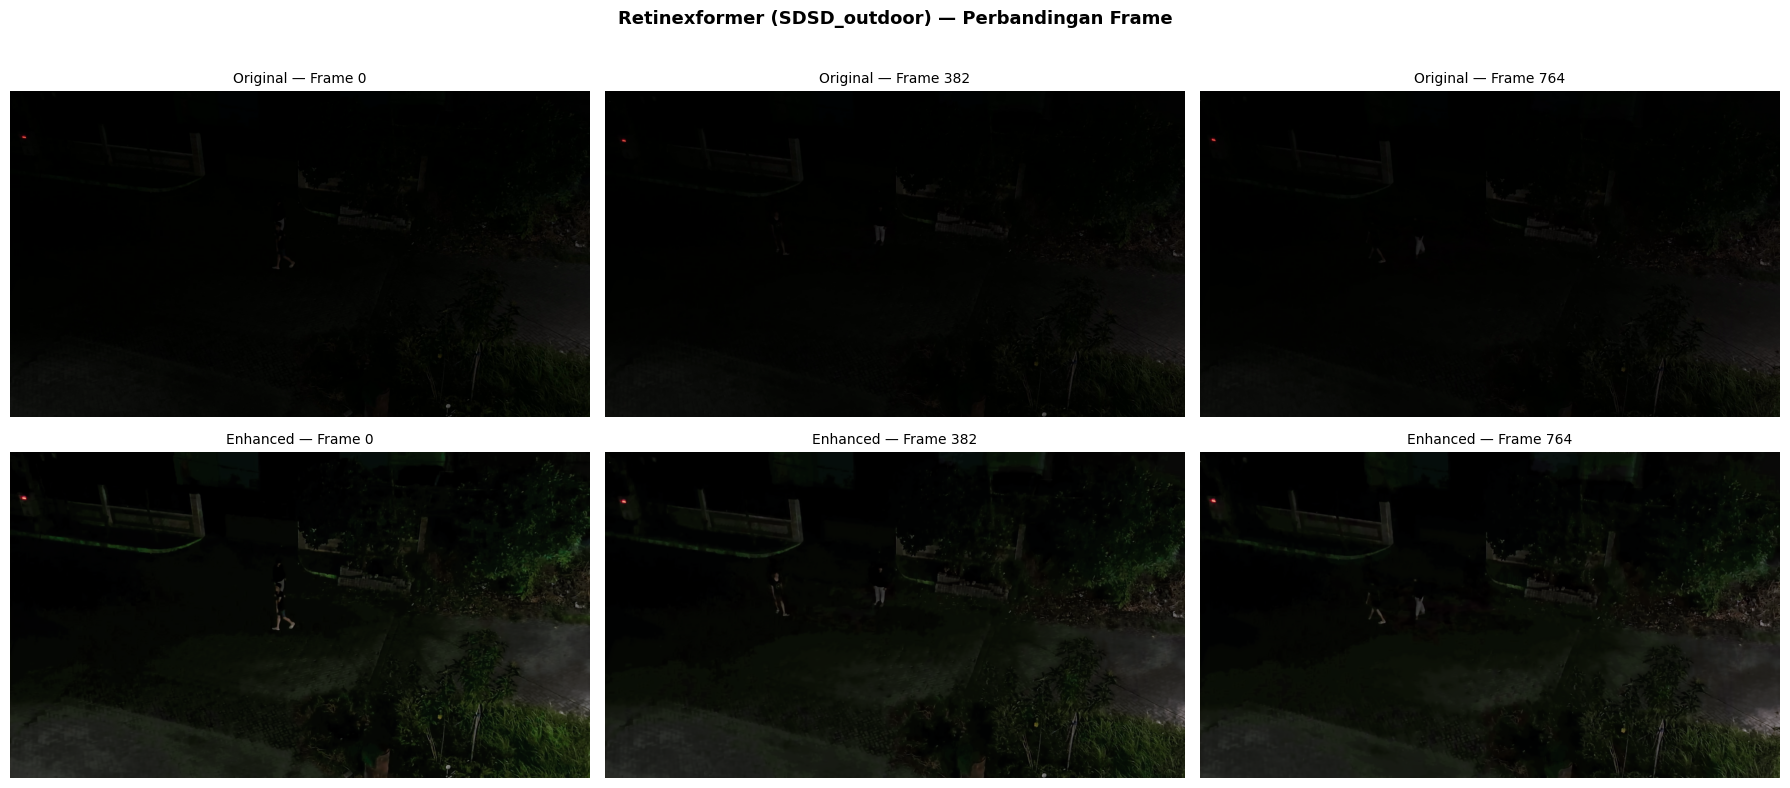

✅ Comparison tersimpan: /kaggle/working/results/comparison-retinex-SDSD_outdoor.png


In [6]:
import cv2
import glob
import matplotlib.pyplot as plt

real_paths     = sorted(glob.glob(os.path.join(INPUT_DIR,    "*.png")))
enhanced_paths = sorted(glob.glob(os.path.join(ENHANCED_DIR, "*.png")))

# Ambil 3 sample frame (awal, tengah, akhir)
indices = [0, len(real_paths) // 2, len(real_paths) - 1]

fig, axes = plt.subplots(2, len(indices), figsize=(18, 8))
fig.suptitle(f"Retinexformer ({MODEL_NAME}) — Perbandingan Frame",
             fontsize=13, fontweight="bold", y=1.01)

for col, idx in enumerate(indices):
    real     = cv2.cvtColor(cv2.imread(real_paths[idx]),     cv2.COLOR_BGR2RGB)
    enhanced = cv2.cvtColor(cv2.imread(enhanced_paths[idx]), cv2.COLOR_BGR2RGB)

    axes[0, col].imshow(real)
    axes[0, col].set_title(f"Original — Frame {idx}", fontsize=10)
    axes[0, col].axis("off")

    axes[1, col].imshow(enhanced)
    axes[1, col].set_title(f"Enhanced — Frame {idx}", fontsize=10)
    axes[1, col].axis("off")

plt.tight_layout()

out_png = os.path.join(RESULTS_DIR, f"comparison-retinex-{MODEL_NAME}.png")
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Comparison tersimpan: {out_png}")

---
## Step 6 — Evaluasi Metrik (PSNR & SSIM)

In [7]:
import random
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

SAMPLE_SIZE = min(30, len(real_paths))
sample_idx  = sorted(random.sample(range(len(real_paths)), SAMPLE_SIZE))

psnr_list, ssim_list = [], []

for idx in sample_idx:
    orig = cv2.imread(real_paths[idx],     cv2.IMREAD_GRAYSCALE)
    enh  = cv2.imread(enhanced_paths[idx], cv2.IMREAD_GRAYSCALE)

    # Fix shape mismatch (orig 4K vs enh 2560)
    if orig.shape != enh.shape:
        orig = cv2.resize(orig, (enh.shape[1], enh.shape[0]), interpolation=cv2.INTER_LINEAR)

    psnr_list.append(psnr(orig, enh, data_range=255))
    ssim_list.append(ssim(orig, enh, data_range=255))

print(f"📊 Evaluasi Metrik — Retinexformer ({MODEL_NAME}) — sample {SAMPLE_SIZE} frame")
print(f"   Avg PSNR : {np.mean(psnr_list):.4f} dB")
print(f"   Avg SSIM : {np.mean(ssim_list):.4f}")

📊 Evaluasi Metrik — Retinexformer (SDSD_outdoor) — sample 30 frame
   Avg PSNR : 26.1499 dB
   Avg SSIM : 0.5337


---
## Step 7 — Gabungkan Frame menjadi Video

In [8]:
images = sorted([
    f for f in os.listdir(ENHANCED_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

if not images:
    raise RuntimeError(f"Tidak ada frame di {ENHANCED_DIR}")

first_frame = cv2.imread(os.path.join(ENHANCED_DIR, images[0]))
h, w, _     = first_frame.shape

print(f"🎬 Menggabungkan {len(images)} frame → {OUTPUT_VIDEO}")
print(f"   Resolusi : {w} x {h} | FPS : {FPS}")
print()

writer = cv2.VideoWriter(OUTPUT_VIDEO, cv2.VideoWriter_fourcc(*"mp4v"), FPS, (w, h))

for i, name in enumerate(images):
    writer.write(cv2.imread(os.path.join(ENHANCED_DIR, name)))
    if i % 100 == 0:
        print(f"  [{i:>6}/{len(images)}] digabungkan...")

writer.release()
print(f"\n✅ Video tersimpan: {OUTPUT_VIDEO}")

🎬 Menggabungkan 765 frame → /kaggle/working/output-retinex-SDSD_outdoor.mp4
   Resolusi : 2560 x 1440 | FPS : 30

  [     0/765] digabungkan...
  [   100/765] digabungkan...
  [   200/765] digabungkan...
  [   300/765] digabungkan...
  [   400/765] digabungkan...
  [   500/765] digabungkan...
  [   600/765] digabungkan...
  [   700/765] digabungkan...

✅ Video tersimpan: /kaggle/working/output-retinex-SDSD_outdoor.mp4
